# Prediksi Gagal Bayar Kartu Kredit Menggunakan Ensemble Learning

Notebook revisi responsi ini membandingkan **Baseline, Bagging, Boosting, Stacking**, serta menambahkan referensi dan eksperimen penanganan **data imbalance**.

Fokus revisi:
1. Ada referensi jurnal untuk imbalance/SMOTE.
2. Ada alasan algoritmik kenapa Stacking dipilih.
3. Grafik perbandingan diurutkan dari skor terbesar ke terkecil.

## 1. Import Library

In [1]:
%pip install -q xgboost lightgbm imbalanced-learn



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier,
    StackingClassifier
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    print('XGBoost tidak tersedia:', e)

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except Exception as e:
    LGBM_AVAILABLE = False
    print('LightGBM tidak tersedia:', e)

try:
    from imblearn.over_sampling import SMOTE
    IMB_AVAILABLE = True
except Exception as e:
    IMB_AVAILABLE = False
    print('imbalanced-learn tidak tersedia:', e)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [3]:
DATA_PATH = 'UCI_Credit_Card.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError('File UCI_Credit_Card.csv tidak ditemukan. Simpan dataset di folder yang sama dengan notebook.')

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3. Data Understanding Singkat
Target: `default.payment.next.month`

- `0` = tidak gagal bayar
- `1` = gagal bayar

In [4]:
print('Missing value total:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print()
print('Distribusi target:')
display(df['default.payment.next.month'].value_counts().to_frame('count'))
display((df['default.payment.next.month'].value_counts(normalize=True) * 100).round(2).to_frame('percent'))

Missing value total: 0
Duplicate rows: 0

Distribusi target:


,count
default.payment.next.month,
0,23364
1,6636


,percent
default.payment.next.month,
0,77.88
1,22.12


## 4. Referensi Penanganan Data Imbalance
Pada kasus financial risk seperti credit default/fraud detection, kelas minoritas adalah kelas penting. Jika model terlalu fokus pada kelas mayoritas, accuracy bisa tinggi tetapi kelas default gagal terdeteksi.

Referensi yang digunakan:

1. **Chawla et al. (2002)** memperkenalkan **SMOTE** untuk membuat sampel sintetis kelas minoritas.
2. **He & Garcia (2009)** menjelaskan bahwa imbalanced learning membuat classifier cenderung bias terhadap kelas mayoritas, sehingga evaluasi perlu memakai metrik selain accuracy.
3. **Aburbeian & Ashqar (2023)** menerapkan SMOTE dan Random Forest untuk credit card fraud detection yang datanya sangat imbalanced.

Pada project ini, imbalance ditangani melalui **class weight**, **scale_pos_weight**, **threshold tuning**, dan eksperimen **SMOTE** sebagai pembanding.

## 5. Cleaning dan Feature Engineering

In [5]:
def prepare_credit_features(data):
    dfc = data.copy()

    dfc['SEX_clean'] = dfc['SEX'].map({1: 'Male', 2: 'Female'}).fillna('Unknown')
    dfc['EDUCATION_clean'] = dfc['EDUCATION'].replace({0: 4, 5: 4, 6: 4}).map({
        1: 'Graduate School', 2: 'University', 3: 'High School', 4: 'Others/Unknown'
    }).fillna('Others/Unknown')
    dfc['MARRIAGE_clean'] = dfc['MARRIAGE'].replace({0: 3}).map({
        1: 'Married', 2: 'Single', 3: 'Others/Unknown'
    }).fillna('Others/Unknown')

    pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
    pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

    delay_only = dfc[pay_cols].clip(lower=0)
    dfc['max_delay'] = delay_only.max(axis=1)
    dfc['avg_delay'] = delay_only.mean(axis=1)
    dfc['recent_delay'] = dfc['PAY_0'].clip(lower=0)
    dfc['late_payment_count'] = (delay_only > 0).sum(axis=1)
    dfc['severe_delay_count'] = (delay_only >= 2).sum(axis=1)
    dfc['is_ever_late'] = (dfc['late_payment_count'] > 0).astype(int)

    dfc['total_bill'] = dfc[bill_cols].sum(axis=1)
    dfc['avg_bill'] = dfc[bill_cols].mean(axis=1)
    dfc['max_bill'] = dfc[bill_cols].max(axis=1)
    dfc['bill_std'] = dfc[bill_cols].std(axis=1)
    dfc['bill_trend'] = dfc['BILL_AMT1'] - dfc['BILL_AMT6']

    dfc['total_payment'] = dfc[pay_amt_cols].sum(axis=1)
    dfc['avg_payment'] = dfc[pay_amt_cols].mean(axis=1)
    dfc['max_payment'] = dfc[pay_amt_cols].max(axis=1)
    dfc['payment_std'] = dfc[pay_amt_cols].std(axis=1)
    dfc['payment_trend'] = dfc['PAY_AMT1'] - dfc['PAY_AMT6']

    eps = 1e-6
    dfc['payment_ratio'] = dfc['total_payment'] / (dfc['total_bill'].abs() + eps)
    dfc['credit_utilization'] = dfc['avg_bill'] / (dfc['LIMIT_BAL'] + eps)
    dfc['bill_to_limit_ratio'] = dfc['total_bill'] / (dfc['LIMIT_BAL'] + eps)
    dfc['payment_to_limit_ratio'] = dfc['total_payment'] / (dfc['LIMIT_BAL'] + eps)
    dfc['recent_pay_to_bill_ratio'] = dfc['PAY_AMT1'] / (dfc['BILL_AMT1'].abs() + eps)

    dfc['age_group'] = pd.cut(
        dfc['AGE'], bins=[20, 30, 40, 50, 60, 80],
        labels=['20-30', '31-40', '41-50', '51-60', '60+'], include_lowest=True
    ).astype(str)

    dfc['limit_group'] = pd.qcut(
        dfc['LIMIT_BAL'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop'
    ).astype(str)

    return dfc

processed_df = prepare_credit_features(df)
print('Processed shape:', processed_df.shape)
display(processed_df.head())

Processed shape: (30000, 51)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,SEX_clean,EDUCATION_clean,MARRIAGE_clean,max_delay,avg_delay,recent_delay,late_payment_count,severe_delay_count,is_ever_late,total_bill,avg_bill,max_bill,bill_std,bill_trend,total_payment,avg_payment,max_payment,payment_std,payment_trend,payment_ratio,credit_utilization,bill_to_limit_ratio,payment_to_limit_ratio,recent_pay_to_bill_ratio,age_group,limit_group
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,Female,University,Married,2,0.666667,2,2,2,1,7704.0,1284.000000,3913.0,1761.633219,3913.0,689.0,114.833333,689.0,281.283072,0.0,0.089434,0.064200,0.385200,0.034450,0.000000,20-30,Low
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,Female,University,Single,2,0.666667,0,2,2,1,17077.0,2846.166667,3455.0,637.967841,-579.0,5000.0,833.333333,2000.0,752.772653,-2000.0,0.292791,0.023718,0.142308,0.041667,0.000000,20-30,Medium
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,Female,University,Single,0,0.000000,0,0,0,0,101653.0,16942.166667,29239.0,6064.518593,13690.0,11018.0,1836.333333,5000.0,1569.815488,-3482.0,0.108388,0.188246,1.129478,0.122422,0.051917,31-40,Medium
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,Female,University,Married,0,0.000000,0,0,0,0,231334.0,38555.666667,49291.0,10565.793518,17443.0,8388.0,1398.000000,2019.0,478.058155,1000.0,0.036259,0.771113,4.626680,0.167760,0.042562,31-40,Low
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,Male,University,Married,0,0.000000,0,0,0,0,109339.0,18223.166667,35835.0,10668.590074,-10514.0,59049.0,9841.500000,36681.0,13786.230736,1321.0,0.540054,0.364463,2.186780,1.180980,0.232099,51-60,Low


## 6. EDA Singkat

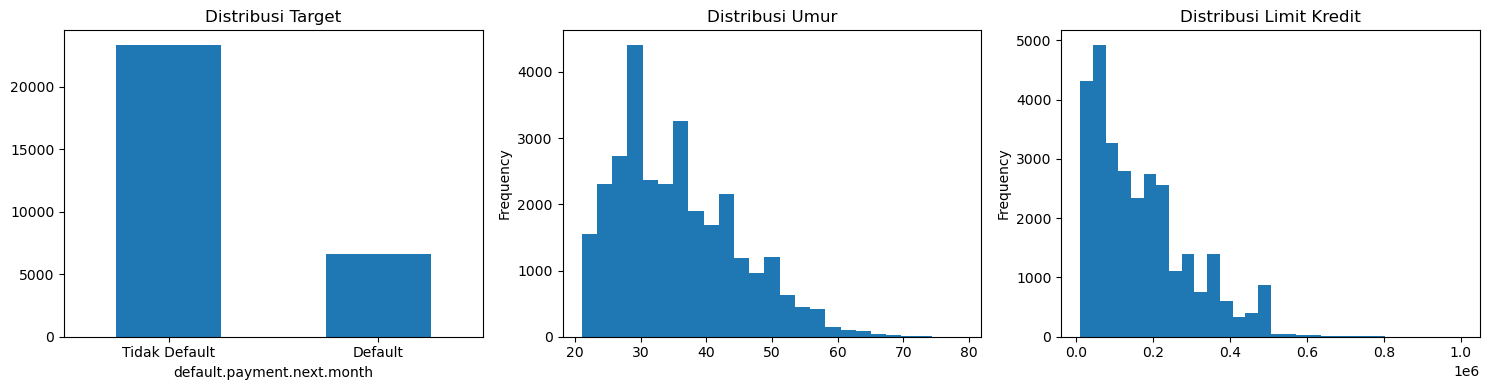

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

processed_df['default.payment.next.month'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribusi Target')
axes[0].set_xticklabels(['Tidak Default', 'Default'], rotation=0)

processed_df['AGE'].plot(kind='hist', bins=25, ax=axes[1])
axes[1].set_title('Distribusi Umur')

processed_df['LIMIT_BAL'].plot(kind='hist', bins=30, ax=axes[2])
axes[2].set_title('Distribusi Limit Kredit')

plt.tight_layout()
plt.show()

## 7. Split Data dan Preprocessing

In [7]:
target_col = 'default.payment.next.month'

categorical_features = ['SEX_clean', 'EDUCATION_clean', 'MARRIAGE_clean', 'age_group', 'limit_group']
original_numeric_features = [
    'LIMIT_BAL', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]
engineered_features = [
    'max_delay', 'avg_delay', 'recent_delay', 'late_payment_count', 'severe_delay_count', 'is_ever_late',
    'total_bill', 'avg_bill', 'max_bill', 'bill_std', 'bill_trend',
    'total_payment', 'avg_payment', 'max_payment', 'payment_std', 'payment_trend',
    'payment_ratio', 'credit_utilization', 'bill_to_limit_ratio', 'payment_to_limit_ratio', 'recent_pay_to_bill_ratio'
]
numeric_features = original_numeric_features + engineered_features
feature_cols = categorical_features + numeric_features

X = processed_df[feature_cols]
y = processed_df[target_col]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=RANDOM_STATE
)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ohe, categorical_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop'
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print('Train:', X_train_prep.shape)
print('Validation:', X_val_prep.shape)
print('Test:', X_test_prep.shape)
print('Distribusi train:', y_train.value_counts(normalize=True).round(3).to_dict())

Train: (18000, 59)
Validation: (6000, 59)
Test: (6000, 59)
Distribusi train: {0: 0.779, 1: 0.221}


## 8. Model yang Dibandingkan

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', round(scale_pos_weight, 3))

models = {
    'Logistic Regression (Baseline)': {
        'category': 'Baseline',
        'model': LogisticRegression(max_iter=800, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
    },
    'Decision Tree (Baseline)': {
        'category': 'Baseline',
        'model': DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight='balanced', random_state=RANDOM_STATE)
    },
    'Random Forest (Bagging)': {
        'category': 'Bagging',
        'model': RandomForestClassifier(n_estimators=60, max_depth=8, min_samples_leaf=12, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
    },
    'Extra Trees (Bagging)': {
        'category': 'Bagging',
        'model': ExtraTreesClassifier(n_estimators=60, max_depth=8, min_samples_leaf=12, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    },
    'AdaBoost (Boosting)': {
        'category': 'Boosting',
        'model': AdaBoostClassifier(n_estimators=60, learning_rate=0.05, random_state=RANDOM_STATE)
    },
    'HistGradientBoosting (Boosting)': {
        'category': 'Boosting',
        'model': HistGradientBoostingClassifier(max_iter=80, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.10, random_state=RANDOM_STATE)
    },
}

if XGB_AVAILABLE:
    models['XGBoost (Boosting)'] = {
        'category': 'Boosting',
        'model': XGBClassifier(
            n_estimators=80, learning_rate=0.05, max_depth=3,
            min_child_weight=4, subsample=0.85, colsample_bytree=0.85,
            reg_lambda=2.0, objective='binary:logistic', eval_metric='logloss',
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1
        )
    }

if LGBM_AVAILABLE:
    models['LightGBM (Boosting)'] = {
        'category': 'Boosting',
        'model': LGBMClassifier(
            n_estimators=80, learning_rate=0.05, max_depth=4,
            num_leaves=24, min_child_samples=50,
            subsample=0.85, colsample_bytree=0.85,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
    }

# Stacking RF + ET + HGB
stacking_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=60, max_depth=7, min_samples_leaf=12, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=60, max_depth=7, min_samples_leaf=12, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        ('hgb', HistGradientBoostingClassifier(max_iter=80, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.10, random_state=RANDOM_STATE))
    ],
    final_estimator=LogisticRegression(max_iter=800, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE),
    stack_method='predict_proba',
    cv=3,
    n_jobs=-1
)
models['Stacking (RF + ET + HGB)'] = {'category': 'Stacking', 'model': stacking_model}

# SMOTE sebagai eksperimen pembanding, tidak otomatis menggantikan model utama
RUN_SMOTE_EXPERIMENT = False
if IMB_AVAILABLE and RUN_SMOTE_EXPERIMENT:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train)
    print('SMOTE train shape:', X_train_smote.shape, pd.Series(y_train_smote).value_counts().to_dict())
else:
    X_train_smote, y_train_smote = None, None

if IMB_AVAILABLE and RUN_SMOTE_EXPERIMENT:
    models['SMOTE + Random Forest (Imbalance)'] = {
        'category': 'Imbalance Experiment',
        'model': RandomForestClassifier(n_estimators=60, max_depth=8, min_samples_leaf=12, random_state=RANDOM_STATE, n_jobs=-1)
    }

for name, item in models.items():
    print('-', name, '[', item['category'], ']')

scale_pos_weight: 3.52
SMOTE train shape: (28036, 59) {0: 14018, 1: 14018}
- Logistic Regression (Baseline) [ Baseline ]
- Decision Tree (Baseline) [ Baseline ]
- Random Forest (Bagging) [ Bagging ]
- Extra Trees (Bagging) [ Bagging ]
- AdaBoost (Boosting) [ Boosting ]
- HistGradientBoosting (Boosting) [ Boosting ]
- XGBoost (Boosting) [ Boosting ]
- LightGBM (Boosting) [ Boosting ]
- Stacking (RF + ET + HGB) [ Stacking ]
- SMOTE + Random Forest (Imbalance) [ Imbalance Experiment ]


## 9. Evaluasi dan Threshold Tuning

In [9]:
def get_model_proba(model, X_data):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_data)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return model.predict(X_data)


def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.10, 0.91, 0.01)
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        rows.append({
            'threshold': float(threshold),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(by=['f1_score', 'recall'], ascending=False).iloc[0]
    return float(best_row['threshold']), threshold_df


def fit_and_evaluate(model_name, category, model):
    # SMOTE model memakai data training hasil resampling, model lain pakai training asli
    if model_name.startswith('SMOTE') and X_train_smote is not None:
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_prep, y_train)

    val_proba = get_model_proba(model, X_val_prep)
    best_threshold, threshold_df = find_best_threshold(y_val, val_proba)

    test_proba = get_model_proba(model, X_test_prep)
    test_pred = (test_proba >= best_threshold).astype(int)

    metrics = {
        'Category': category,
        'Model': model_name,
        'Threshold': best_threshold,
        'Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred, zero_division=0),
        'Recall': recall_score(y_test, test_pred, zero_division=0),
        'F1-score': f1_score(y_test, test_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, test_proba),
        'PR-AUC': average_precision_score(y_test, test_proba)
    }
    return metrics, model, test_pred, test_proba, threshold_df

## 10. Training Semua Model

In [10]:
results = []
fitted_models = {}
predictions = {}
probabilities = {}
threshold_tables = {}

for model_name, item in models.items():
    print('Training:', model_name)
    metrics, fitted_model, y_pred_test, y_proba_test, threshold_df = fit_and_evaluate(
        model_name, item['category'], item['model']
    )
    results.append(metrics)
    fitted_models[model_name] = fitted_model
    predictions[model_name] = y_pred_test
    probabilities[model_name] = y_proba_test
    threshold_tables[model_name] = threshold_df

results_df = pd.DataFrame(results).sort_values(
    by=['F1-score', 'ROC-AUC', 'PR-AUC'], ascending=False
).reset_index(drop=True)

display(results_df)

Training: Logistic Regression (Baseline)
Training: Decision Tree (Baseline)
Training: Random Forest (Bagging)
Training: Extra Trees (Bagging)
Training: AdaBoost (Boosting)
Training: HistGradientBoosting (Boosting)
Training: XGBoost (Boosting)
Training: LightGBM (Boosting)
Training: Stacking (RF + ET + HGB)
Training: SMOTE + Random Forest (Imbalance)


,Category,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Stacking,Stacking (RF + ET + HGB),0.60,0.793833,0.532468,0.556142,0.544047,0.778044,0.558895
1,Boosting,HistGradientBoosting (Boosting),0.30,0.795667,0.537105,0.550867,0.543899,0.779648,0.560297
2,Boosting,LightGBM (Boosting),0.59,0.797167,0.541168,0.544838,0.542997,0.783109,0.556469
3,Boosting,XGBoost (Boosting),0.56,0.785333,0.513329,0.565938,0.538351,0.780114,0.551457
4,Bagging,Random Forest (Bagging),0.52,0.776000,0.494630,0.590053,0.538144,0.776841,0.555523
5,Boosting,AdaBoost (Boosting),0.42,0.778167,0.498672,0.565938,0.530180,0.758172,0.516498
6,Bagging,Extra Trees (Bagging),0.63,0.802167,0.558528,0.503391,0.529528,0.766218,0.543787
7,Imbalance Experiment,SMOTE + Random Forest (Imbalance),0.50,0.767667,0.479231,0.582517,0.525850,0.771678,0.546851
8,Baseline,Decision Tree (Baseline),0.60,0.773667,0.489902,0.566692,0.525507,0.760953,0.527259
9,Baseline,Logistic Regression (Baseline),0.57,0.778667,0.499659,0.552374,0.524696,0.761826,0.523269


## 11. Ranking Model dan Best per Kategori

In [11]:
rank_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']
rank_table = results_df[['Category', 'Model'] + rank_metrics].copy()
for metric in rank_metrics:
    rank_table[f'Rank_{metric}'] = rank_table[metric].rank(ascending=False, method='dense').astype(int)
rank_cols = [f'Rank_{m}' for m in rank_metrics]
rank_table['Average_Rank'] = rank_table[rank_cols].mean(axis=1)
rank_table = rank_table.sort_values(by='Average_Rank', ascending=True).reset_index(drop=True)

display(rank_table)

best_by_category = (
    results_df.sort_values(by=['Category', 'F1-score', 'ROC-AUC'], ascending=[True, False, False])
    .groupby('Category').head(1).reset_index(drop=True)
)
display(best_by_category[['Category', 'Model', 'F1-score', 'Recall', 'ROC-AUC', 'PR-AUC', 'Threshold']])

,Category,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Rank_Accuracy,Rank_Precision,Rank_Recall,Rank_F1-score,Rank_ROC-AUC,Rank_PR-AUC,Average_Rank
0,Boosting,HistGradientBoosting (Boosting),0.795667,0.537105,0.550867,0.543899,0.779648,0.560297,3,3,7,2,3,1,3.166667
1,Boosting,LightGBM (Boosting),0.797167,0.541168,0.544838,0.542997,0.783109,0.556469,2,2,8,3,1,3,3.166667
2,Stacking,Stacking (RF + ET + HGB),0.793833,0.532468,0.556142,0.544047,0.778044,0.558895,4,4,5,1,4,2,3.333333
3,Boosting,XGBoost (Boosting),0.785333,0.513329,0.565938,0.538351,0.780114,0.551457,5,5,4,4,2,5,4.166667
4,Bagging,Random Forest (Bagging),0.776000,0.494630,0.590053,0.538144,0.776841,0.555523,8,8,1,5,5,4,5.166667
5,Bagging,Extra Trees (Bagging),0.802167,0.558528,0.503391,0.529528,0.766218,0.543787,1,1,9,7,7,7,5.333333
6,Imbalance Experiment,SMOTE + Random Forest (Imbalance),0.767667,0.479231,0.582517,0.525850,0.771678,0.546851,10,10,2,8,6,6,7.000000
7,Boosting,AdaBoost (Boosting),0.778167,0.498672,0.565938,0.530180,0.758172,0.516498,7,7,4,6,10,10,7.333333
8,Baseline,Logistic Regression (Baseline),0.778667,0.499659,0.552374,0.524696,0.761826,0.523269,6,6,6,10,8,9,7.500000
9,Baseline,Decision Tree (Baseline),0.773667,0.489902,0.566692,0.525507,0.760953,0.527259,9,9,3,9,9,8,7.833333


,Category,Model,F1-score,Recall,ROC-AUC,PR-AUC,Threshold
0,Bagging,Random Forest (Bagging),0.538144,0.590053,0.776841,0.555523,0.52
1,Baseline,Decision Tree (Baseline),0.525507,0.566692,0.760953,0.527259,0.60
2,Boosting,HistGradientBoosting (Boosting),0.543899,0.550867,0.779648,0.560297,0.30
3,Imbalance Experiment,SMOTE + Random Forest (Imbalance),0.525850,0.582517,0.771678,0.546851,0.50
4,Stacking,Stacking (RF + ET + HGB),0.544047,0.556142,0.778044,0.558895,0.60


## 12. Grafik Perbandingan Model Diurutkan dari Terbesar ke Terkecil

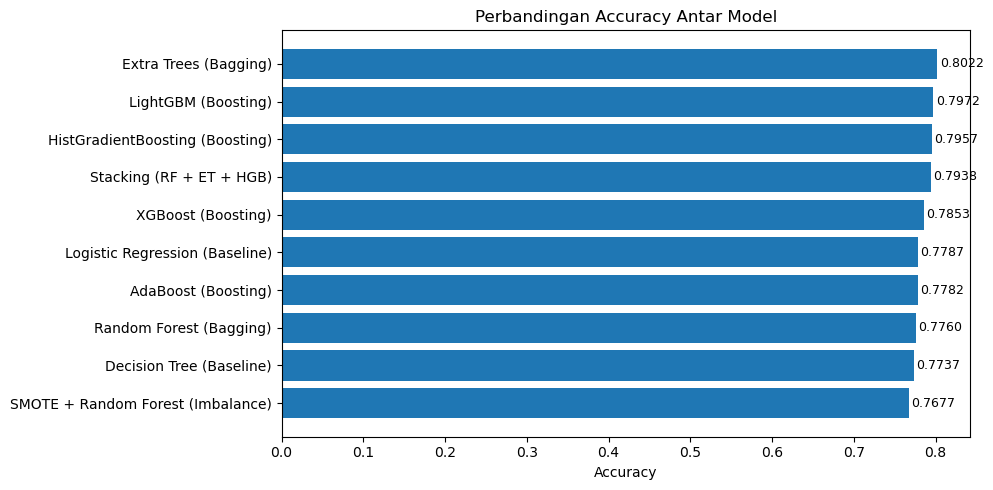

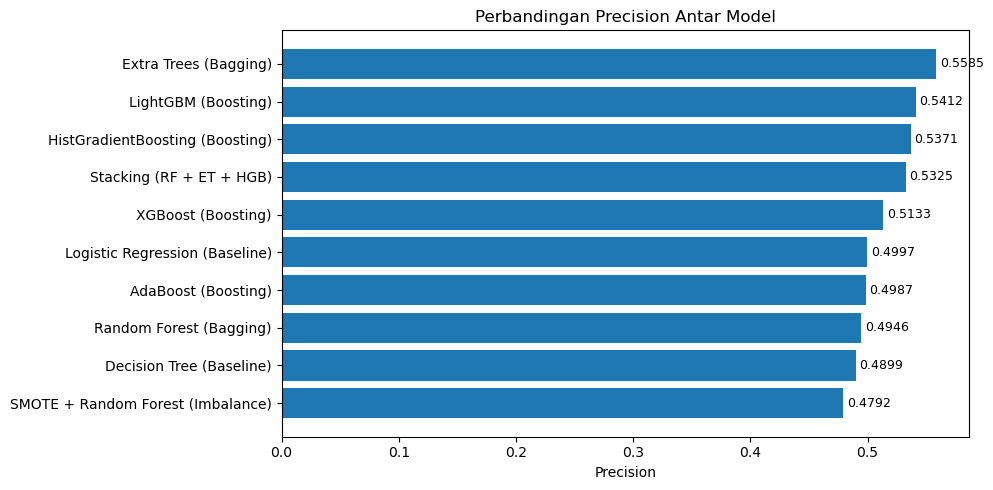

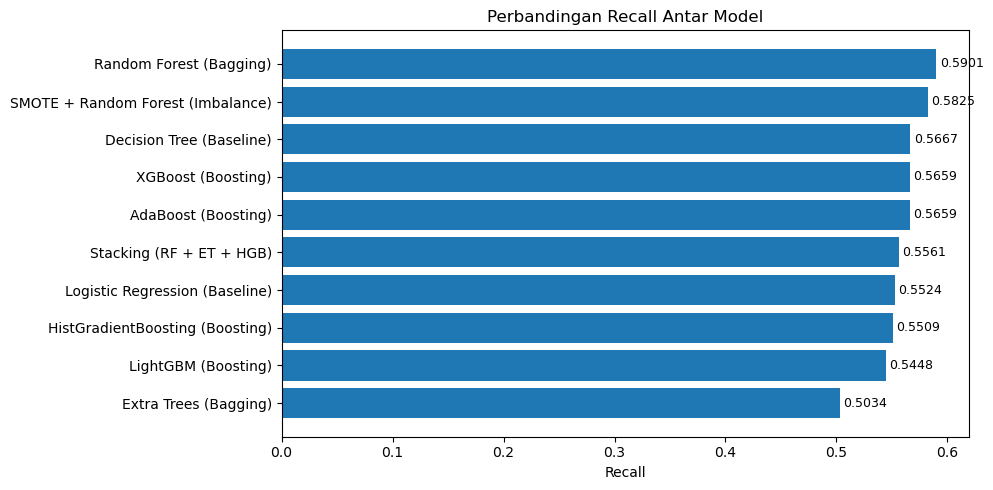

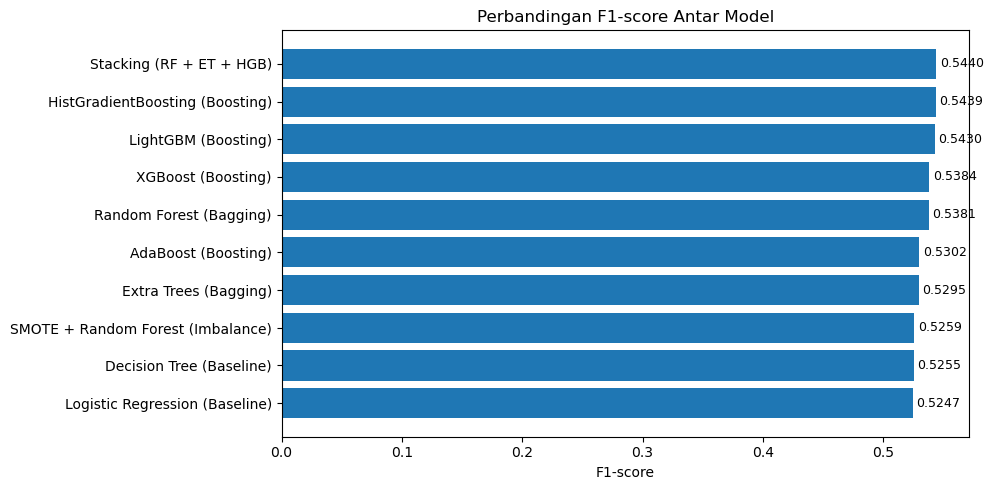

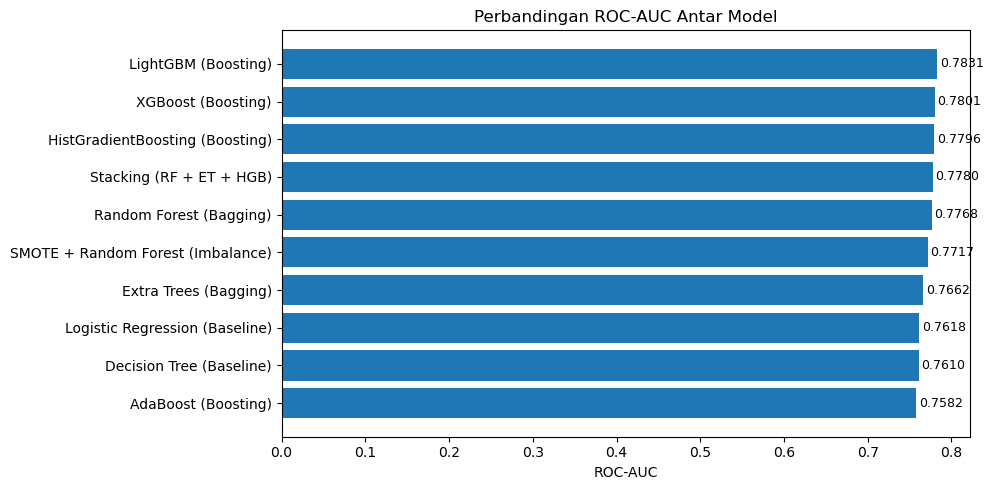

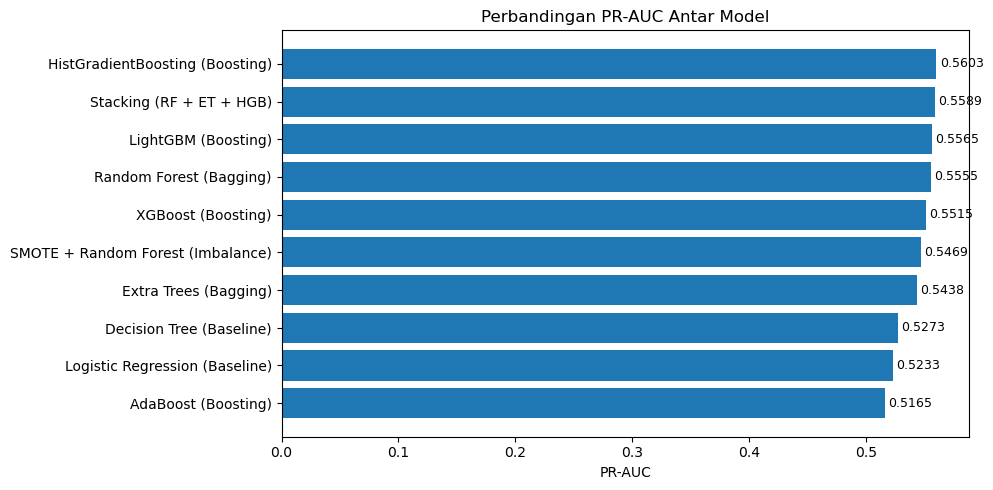

In [12]:
def plot_metric_sorted(df_result, metric):
    plot_df = df_result.sort_values(by=metric, ascending=False).copy()
    plt.figure(figsize=(10, 5))
    plt.barh(plot_df['Model'], plot_df[metric])
    plt.gca().invert_yaxis()
    plt.title(f'Perbandingan {metric} Antar Model')
    plt.xlabel(metric)
    for i, value in enumerate(plot_df[metric]):
        plt.text(value + 0.003, i, f'{value:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']:
    plot_metric_sorted(results_df, metric)

## 13. Classification Report Semua Model

In [13]:
for model_name in results_df['Model']:
    print('=' * 90)
    print(model_name)
    print('Category:', results_df.loc[results_df['Model'] == model_name, 'Category'].iloc[0])
    print('Threshold:', results_df.loc[results_df['Model'] == model_name, 'Threshold'].iloc[0])
    print(classification_report(y_test, predictions[model_name], target_names=['Tidak Default', 'Default'], zero_division=0))

Stacking (RF + ET + HGB)
Category: Stacking
Threshold: 0.5999999999999998
               precision    recall  f1-score   support

Tidak Default       0.87      0.86      0.87      4673
      Default       0.53      0.56      0.54      1327

     accuracy                           0.79      6000
    macro avg       0.70      0.71      0.71      6000
 weighted avg       0.80      0.79      0.80      6000

HistGradientBoosting (Boosting)
Category: Boosting
Threshold: 0.29999999999999993
               precision    recall  f1-score   support

Tidak Default       0.87      0.87      0.87      4673
      Default       0.54      0.55      0.54      1327

     accuracy                           0.80      6000
    macro avg       0.70      0.71      0.71      6000
 weighted avg       0.80      0.80      0.80      6000

LightGBM (Boosting)
Category: Boosting
Threshold: 0.5899999999999997
               precision    recall  f1-score   support

Tidak Default       0.87      0.87      0.87      467

## 14. Confusion Matrix Semua Model

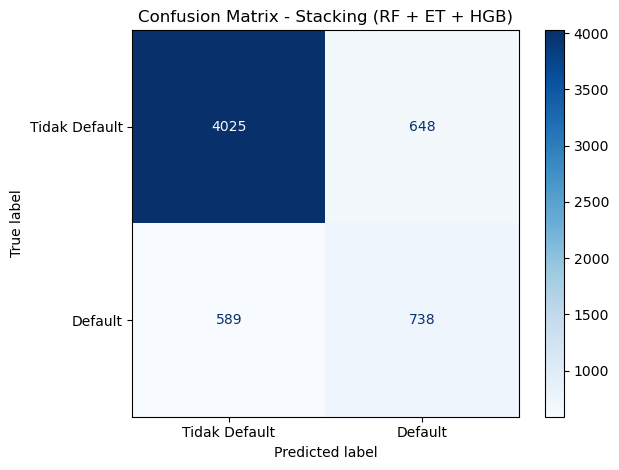

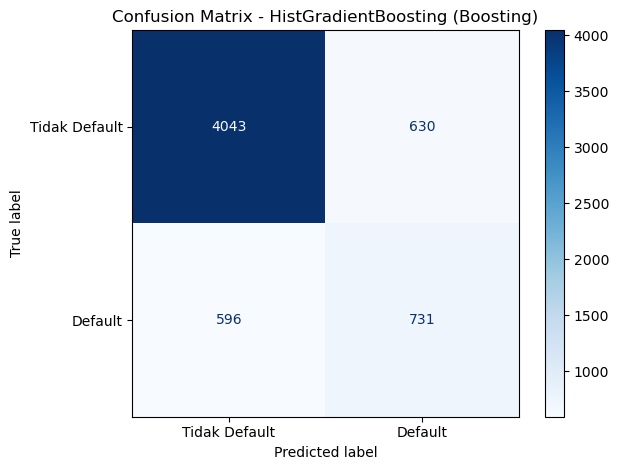

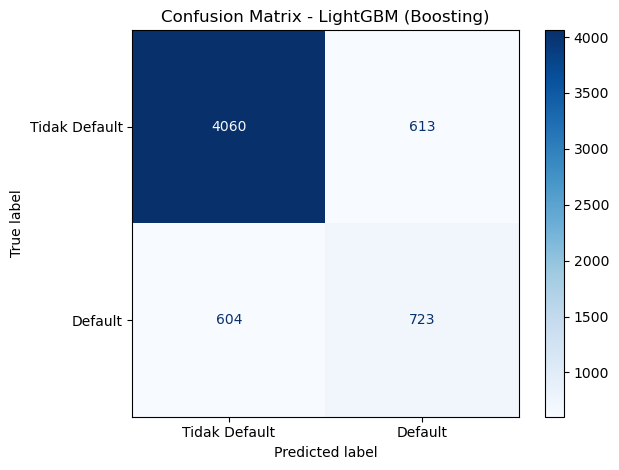

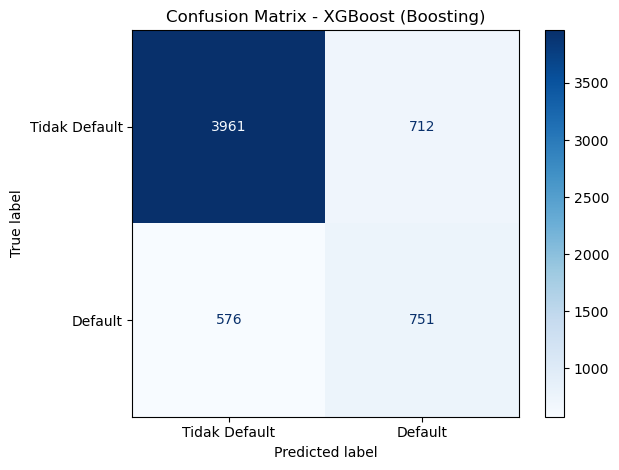

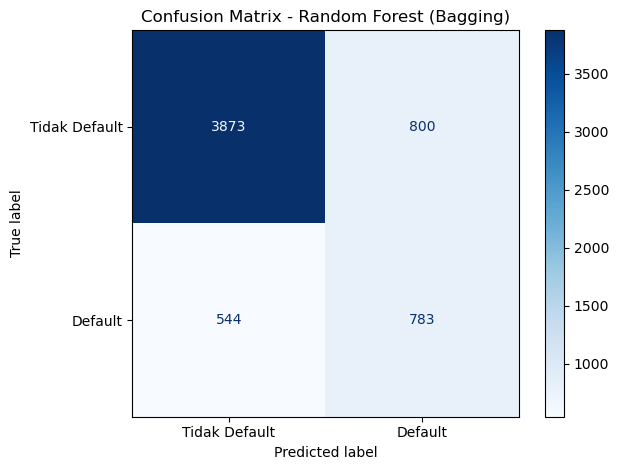

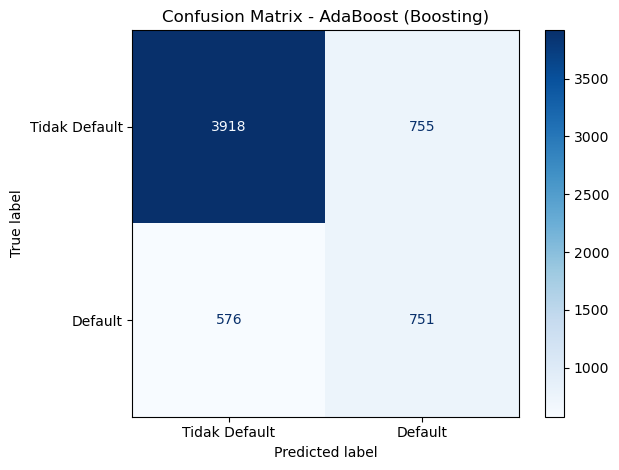

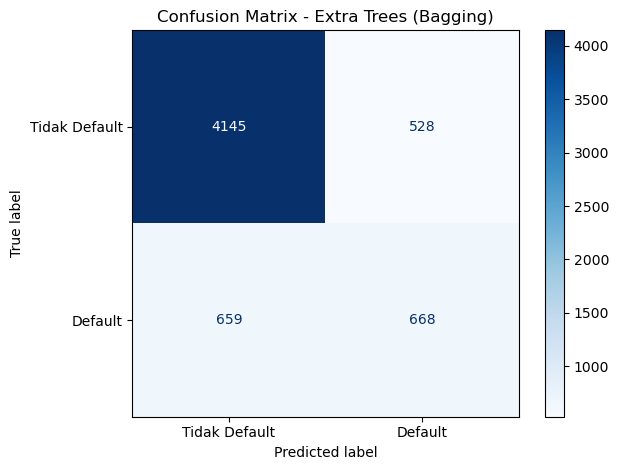

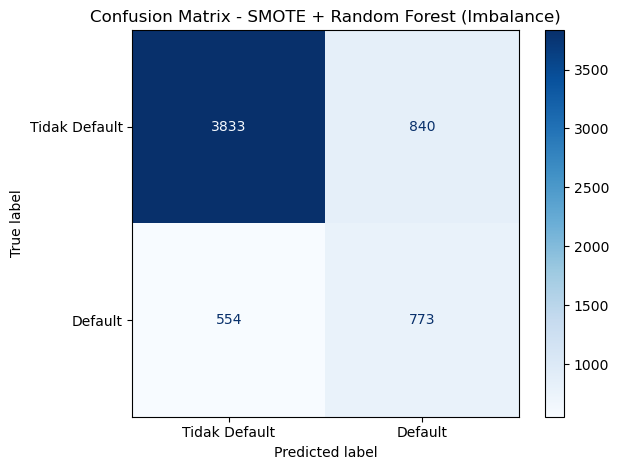

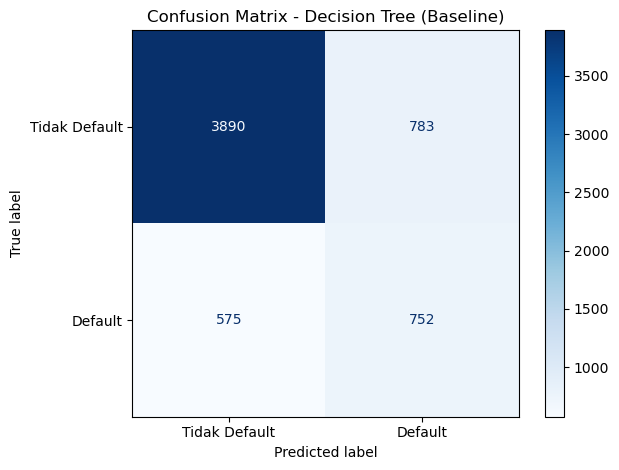

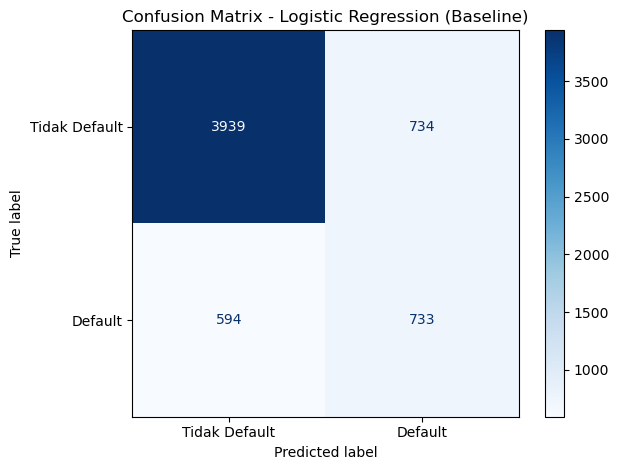

In [14]:
for model_name in results_df['Model']:
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[model_name], display_labels=['Tidak Default', 'Default'], cmap='Blues'
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

## 15. ROC Curve dan Precision-Recall Curve

<Figure size 800x600 with 0 Axes>

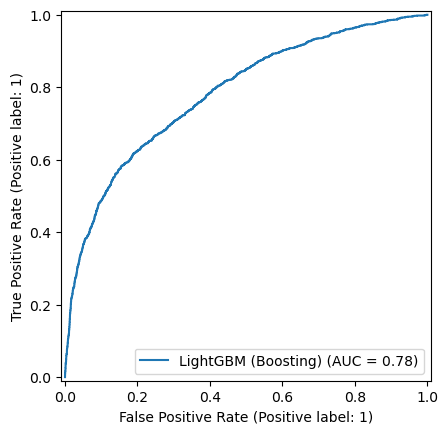

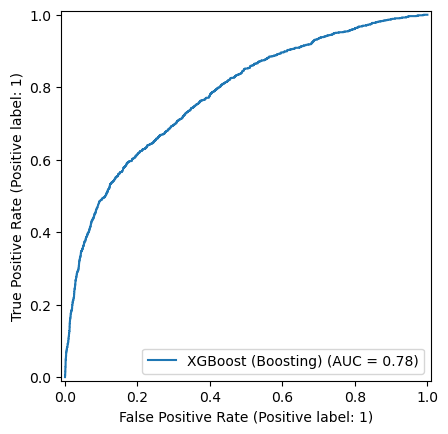

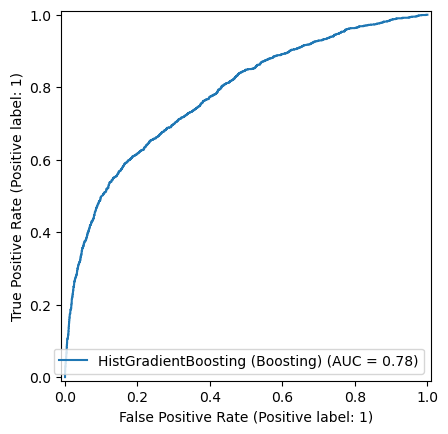

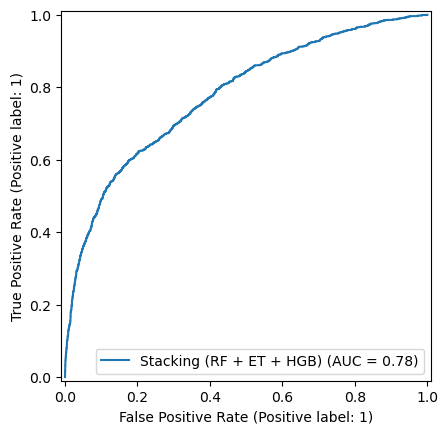

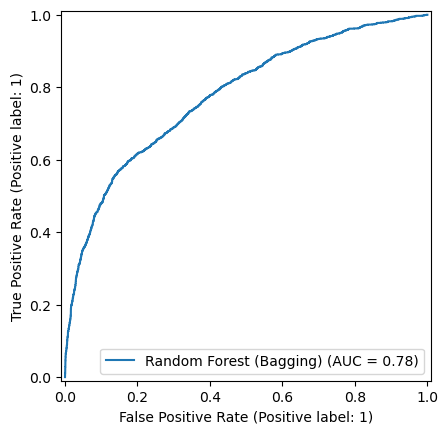

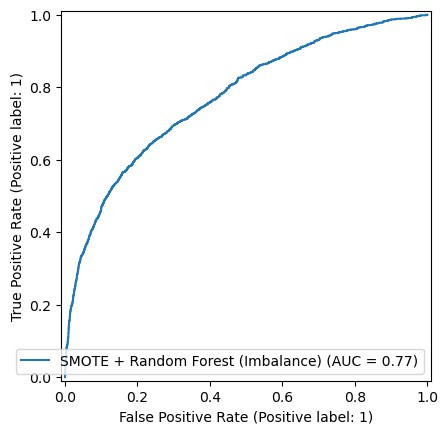

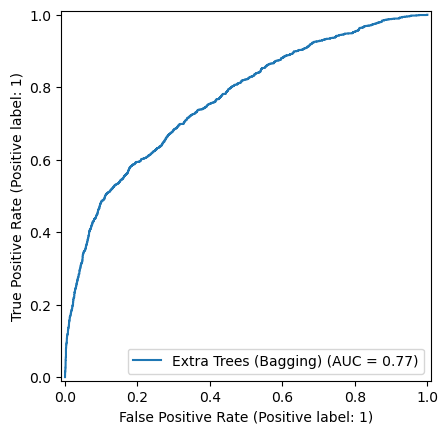

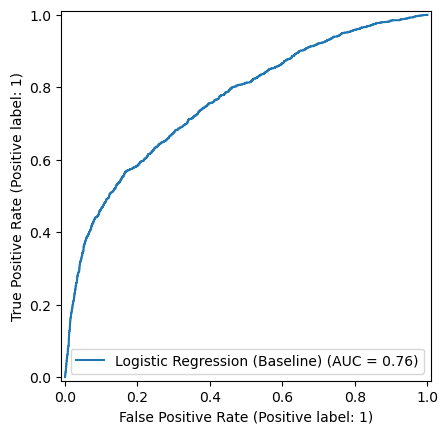

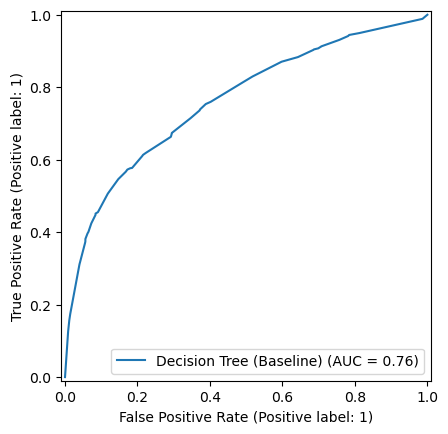

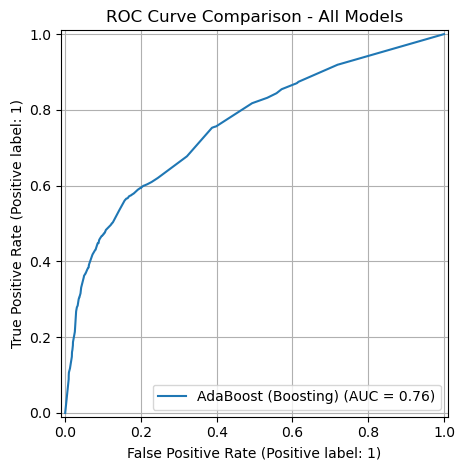

<Figure size 800x600 with 0 Axes>

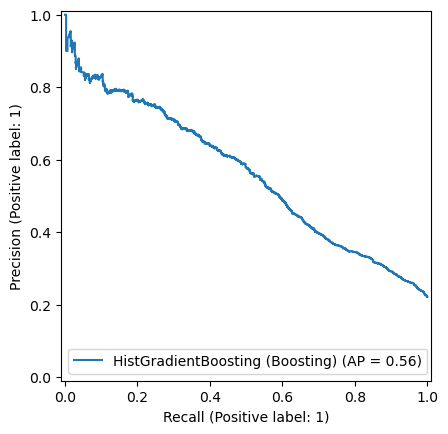

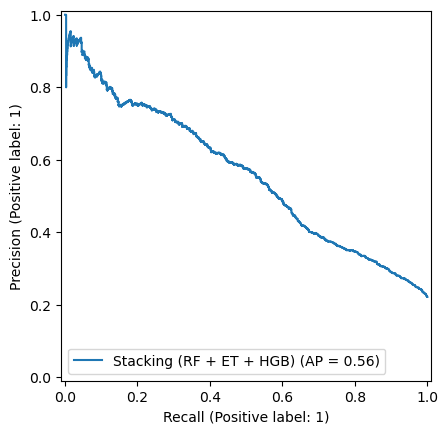

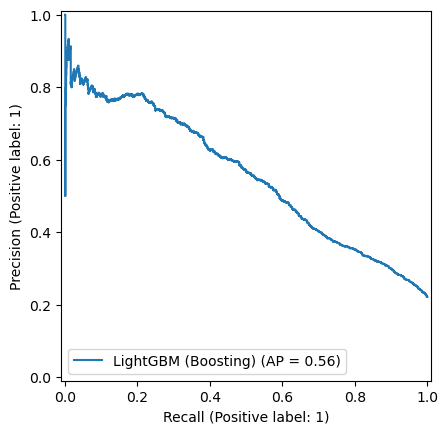

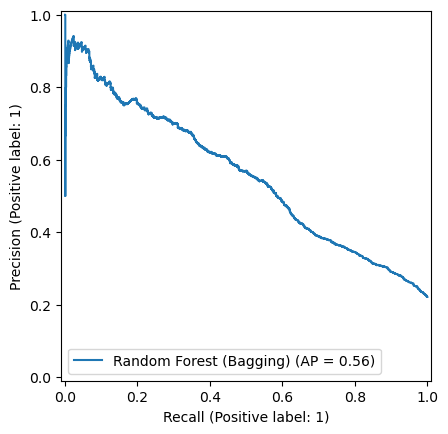

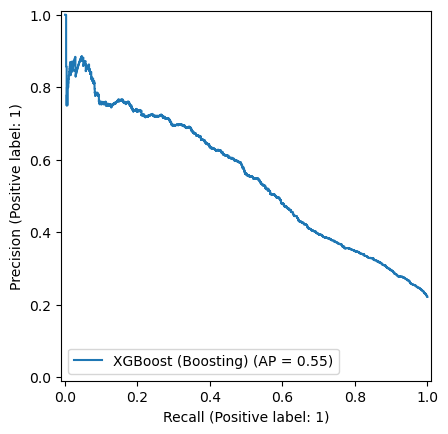

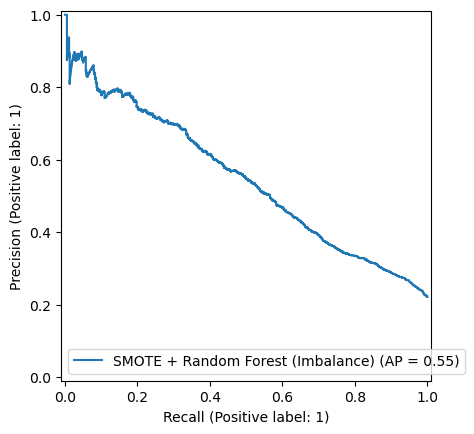

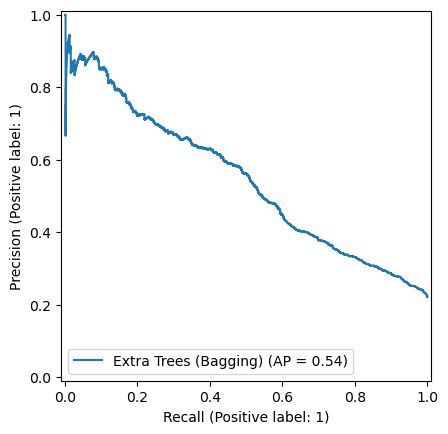

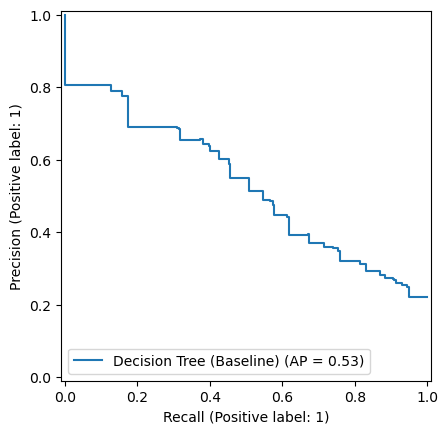

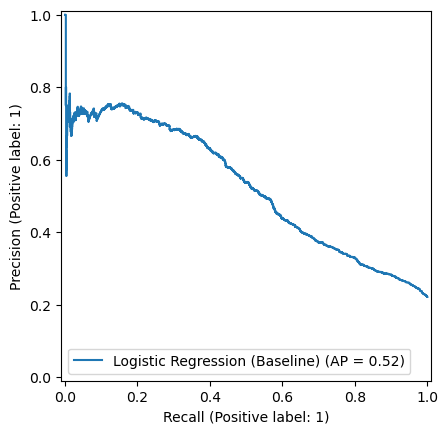

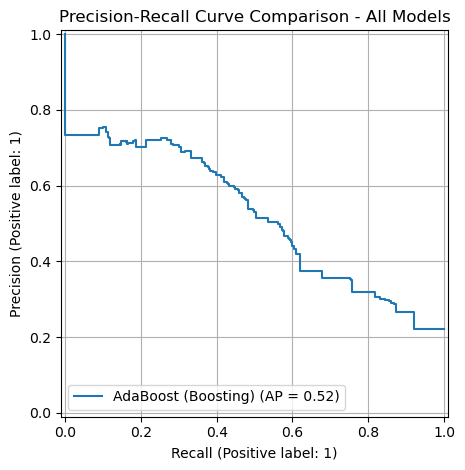

In [15]:
plt.figure(figsize=(8, 6))
for model_name in results_df.sort_values(by='ROC-AUC', ascending=False)['Model']:
    RocCurveDisplay.from_predictions(y_test, probabilities[model_name], name=model_name)
plt.title('ROC Curve Comparison - All Models')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name in results_df.sort_values(by='PR-AUC', ascending=False)['Model']:
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[model_name], name=model_name)
plt.title('Precision-Recall Curve Comparison - All Models')
plt.grid(True)
plt.tight_layout()
plt.show()

## 16. Threshold Tuning Model Terbaik

Best model: Stacking (RF + ET + HGB)
Category: Stacking
Best threshold: 0.5999999999999998


,threshold,precision,recall,f1_score
50,0.60,0.536410,0.560663,0.548268
49,0.59,0.525802,0.568199,0.546179
47,0.57,0.511566,0.583271,0.545070
52,0.62,0.547529,0.542577,0.545042
48,0.58,0.517990,0.574981,0.545000
51,0.61,0.539659,0.548606,0.544096
46,0.56,0.502234,0.593067,0.543884
45,0.55,0.496560,0.598342,0.542720
44,0.54,0.489388,0.608139,0.542339
53,0.63,0.552941,0.531274,0.541891


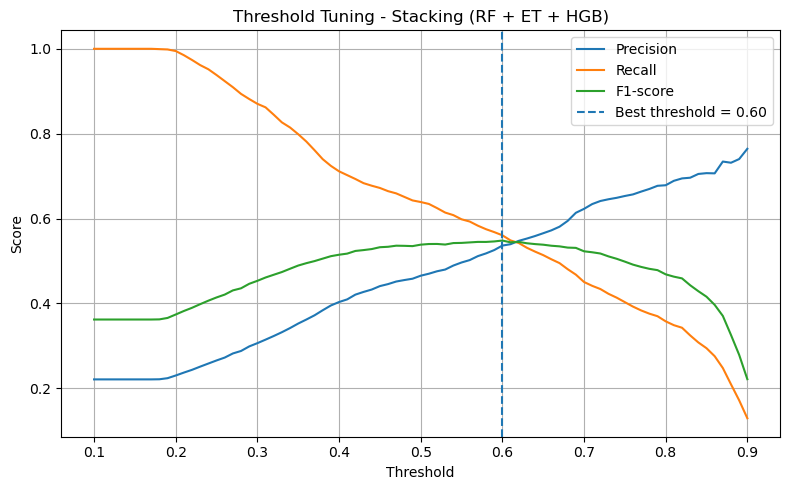

In [16]:
best_model_name = results_df.iloc[0]['Model']
best_category = results_df.iloc[0]['Category']
best_threshold = results_df.iloc[0]['Threshold']

print('Best model:', best_model_name)
print('Category:', best_category)
print('Best threshold:', best_threshold)

display(threshold_tables[best_model_name].sort_values(by='f1_score', ascending=False).head(10))

threshold_df = threshold_tables[best_model_name]
plt.figure(figsize=(8, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1_score'], label='F1-score')
plt.axvline(best_threshold, linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 17. Alasan Pemilihan Stacking
Stacking dipilih bukan hanya berdasarkan skor tertinggi, tetapi karena gabungan algoritmanya saling melengkapi:

- **Random Forest** memberi stabilitas melalui banyak decision tree dan voting.
- **Extra Trees** memberi diversity karena split dibuat lebih acak dibanding Random Forest.
- **HistGradientBoosting** memberi kemampuan koreksi error karena model dibangun bertahap seperti boosting.
- **Meta learner** mempelajari probabilitas dari base model untuk menentukan prediksi akhir.

Jadi Stacking menggabungkan **stability + diversity + error correction**, sehingga secara metodologis masuk akal jika performanya lebih seimbang daripada model tunggal.

## 18. Feature Importance

In [17]:
def get_feature_names():
    try:
        cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
    except Exception:
        cat_names = categorical_features
    return cat_names + numeric_features

feature_names = get_feature_names()

candidate_tree_models = results_df[
    results_df['Model'].str.contains('XGBoost|LightGBM|Random Forest|Extra Trees|HistGradientBoosting|AdaBoost', regex=True)
].copy()

if len(candidate_tree_models) > 0:
    best_tree_name = candidate_tree_models.iloc[0]['Model']
    estimator = fitted_models[best_tree_name]
    print('Best tree-based model for interpretation:', best_tree_name)

    if hasattr(estimator, 'feature_importances_'):
        importances = estimator.feature_importances_
        fi_df = pd.DataFrame({'feature': feature_names[:len(importances)], 'importance': importances})
        fi_df = fi_df.sort_values(by='importance', ascending=False).head(20)
        display(fi_df)

        plt.figure(figsize=(9, 6))
        plt.barh(fi_df['feature'], fi_df['importance'])
        plt.gca().invert_yaxis()
        plt.title(f'Top 20 Feature Importance - {best_tree_name}')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
    else:
        print('Model terpilih tidak memiliki feature_importances_.')
else:
    print('Tidak ada tree-based model untuk feature importance.')

Best tree-based model for interpretation: HistGradientBoosting (Boosting)
Model terpilih tidak memiliki feature_importances_.


## 19. Hasil Prediksi Model Terbaik

In [18]:
best_pred = predictions[best_model_name]
best_proba = probabilities[best_model_name]

prediction_result = X_test.copy()
prediction_result['actual_default'] = y_test.values
prediction_result['predicted_default'] = best_pred
prediction_result['default_probability'] = best_proba
prediction_result['actual_label'] = prediction_result['actual_default'].map({0: 'Tidak Default', 1: 'Default'})
prediction_result['predicted_label'] = prediction_result['predicted_default'].map({0: 'Tidak Default', 1: 'Default'})

cols_to_show = [
    'actual_label', 'predicted_label', 'default_probability',
    'LIMIT_BAL', 'AGE', 'max_delay', 'avg_delay', 'late_payment_count',
    'payment_ratio', 'credit_utilization'
]
display(prediction_result[cols_to_show].head(20))

results_df.to_csv('hasil_perbandingan_model_v3.csv', index=False)
rank_table.to_csv('ranking_model_v3.csv', index=False)
best_by_category.to_csv('best_by_category_v3.csv', index=False)
prediction_result.to_csv('hasil_prediksi_model_terbaik_v3.csv', index=False)
print('Output tersimpan sebagai CSV.')

,actual_label,predicted_label,default_probability,LIMIT_BAL,AGE,max_delay,avg_delay,late_payment_count,payment_ratio,credit_utilization
6907,Tidak Default,Tidak Default,0.318093,50000.0,46,0,0.000000,0,1.003385,0.121113
24575,Tidak Default,Tidak Default,0.284159,150000.0,31,0,0.000000,0,1.561924,0.029660
26766,Tidak Default,Tidak Default,0.390979,50000.0,25,0,0.000000,0,0.039392,0.988530
2156,Default,Tidak Default,0.304906,290000.0,25,0,0.000000,0,0.050182,0.935412
3179,Tidak Default,Tidak Default,0.214112,500000.0,27,0,0.000000,0,1.215185,0.021636
29382,Tidak Default,Default,0.607725,200000.0,29,2,0.500000,2,0.334620,0.982943
24454,Tidak Default,Tidak Default,0.276291,210000.0,31,0,0.000000,0,0.032294,0.525930
23886,Tidak Default,Tidak Default,0.191265,260000.0,35,0,0.000000,0,0.216379,0.178933
5504,Tidak Default,Tidak Default,0.245961,450000.0,42,0,0.000000,0,0.342349,0.032741
29720,Tidak Default,Tidak Default,0.232508,150000.0,39,0,0.000000,0,0.066337,0.149071


Output tersimpan sebagai CSV.


## 20. Kesimpulan Singkat

In [19]:
print('Model terbaik keseluruhan:', best_model_name)
print('Kategori:', best_category)
print()
print('Top 5 model:')
display(results_df.head(5))
print()
print('Model terbaik per kategori:')
display(best_by_category[['Category', 'Model', 'F1-score', 'Recall', 'ROC-AUC', 'PR-AUC', 'Threshold']])

Model terbaik keseluruhan: Stacking (RF + ET + HGB)
Kategori: Stacking

Top 5 model:


,Category,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Stacking,Stacking (RF + ET + HGB),0.60,0.793833,0.532468,0.556142,0.544047,0.778044,0.558895
1,Boosting,HistGradientBoosting (Boosting),0.30,0.795667,0.537105,0.550867,0.543899,0.779648,0.560297
2,Boosting,LightGBM (Boosting),0.59,0.797167,0.541168,0.544838,0.542997,0.783109,0.556469
3,Boosting,XGBoost (Boosting),0.56,0.785333,0.513329,0.565938,0.538351,0.780114,0.551457
4,Bagging,Random Forest (Bagging),0.52,0.776000,0.494630,0.590053,0.538144,0.776841,0.555523



Model terbaik per kategori:


,Category,Model,F1-score,Recall,ROC-AUC,PR-AUC,Threshold
0,Bagging,Random Forest (Bagging),0.538144,0.590053,0.776841,0.555523,0.52
1,Baseline,Decision Tree (Baseline),0.525507,0.566692,0.760953,0.527259,0.60
2,Boosting,HistGradientBoosting (Boosting),0.543899,0.550867,0.779648,0.560297,0.30
3,Imbalance Experiment,SMOTE + Random Forest (Imbalance),0.525850,0.582517,0.771678,0.546851,0.50
4,Stacking,Stacking (RF + ET + HGB),0.544047,0.556142,0.778044,0.558895,0.60


## 21. Daftar Referensi
1. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). **SMOTE: Synthetic Minority Over-sampling Technique**. *Journal of Artificial Intelligence Research*, 16, 321–357.
2. He, H., & Garcia, E. A. (2009). **Learning from Imbalanced Data**. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284.
3. Aburbeian, A. H. M., & Ashqar, H. I. (2023). **Credit Card Fraud Detection Using Enhanced Random Forest Classifier for Imbalanced Data**.
4. Breiman, L. (2001). **Random Forests**. *Machine Learning*, 45, 5–32.
5. Geurts, P., Ernst, D., & Wehenkel, L. (2006). **Extremely Randomized Trees**. *Machine Learning*, 63, 3–42.
6. Wolpert, D. H. (1992). **Stacked Generalization**. *Neural Networks*, 5(2), 241–259.
7. Ting, K. M., & Witten, I. H. (1999). **Issues in Stacked Generalization**.